In [ ]:
from google.colab import drive
drive.mount('/content/drive',force_remount=True)

Mounted at /content/drive


In [ ]:
from google.colab.patches import cv2_imshow

In [ ]:
!git clone https://github.com/AlexeyAB/darknet

Cloning into 'darknet'...
remote: Enumerating objects: 15412, done.
remote: Total 15412 (delta 0), reused 0 (delta 0), pack-reused 15412
Receiving objects: 100% (15412/15412), 14.05 MiB | 18.03 MiB/s, done.
Resolving deltas: 100% (10354/10354), done.


In [ ]:
%cd darknet
!sed -i 's/OPENCV=0/OPENCV=1/' Makefile
!sed -i 's/GPU=0/GPU=1/' Makefile
!sed -i 's/CUDNN=0/CUDNN=1/' Makefile

/content/darknet


In [ ]:
!/usr/local/cuda/bin/nvcc --version

nvcc: NVIDIA (R) Cuda compiler driver
Copyright (c) 2005-2020 NVIDIA Corporation
Built on Mon_Oct_12_20:09:46_PDT_2020
Cuda compilation tools, release 11.1, V11.1.105
Build cuda_11.1.TC455_06.29190527_0


In [ ]:
! make

chmod +x *.sh
gcc -Iinclude/ -I3rdparty/stb/include -DOPENCV `pkg-config --cflags opencv4 2> /dev/null || pkg-config --cflags opencv` -DGPU -I/usr/local/cuda/include/ -DCUDNN -Wall -Wfatal-errors -Wno-unused-result -Wno-unknown-pragmas -fPIC -Ofast -DOPENCV -DGPU -DCUDNN -I/usr/local/cudnn/include -c ./src/yolo.c -o obj/yolo.o
gcc -Iinclude/ -I3rdparty/stb/include -DOPENCV `pkg-config --cflags opencv4 2> /dev/null || pkg-config --cflags opencv` -DGPU -I/usr/local/cuda/include/ -DCUDNN -Wall -Wfatal-errors -Wno-unused-result -Wno-unknown-pragmas -fPIC -Ofast -DOPENCV -DGPU -DCUDNN -I/usr/local/cudnn/include -c ./src/detector.c -o obj/detector.o
./src/detector.c: In function ‘train_detector’:
./src/detector.c:395:72: warning: suggest parentheses around ‘&&’ within ‘||’ [-Wparentheses]
             (iteration >= (iter_save + 1000) || iteration % 1000 == 0) && net.max_batches < 10000)
             ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~^~~~~~~~~~~~~~~~~~~~~~~~~~
./src/d

In [ ]:
import os

In [ ]:
IMG_DIR = r'/content/drive/MyDrive/SCIIproject/annotatedimg'
print(os.listdir(IMG_DIR))

['invoice4b-2.jpg', 'treebo_invoice-1.jpg', 'onstreetcab_invoice-1.jpg', 'inv-7-converted-1.jpg', 'invoice4b-1.jpg', 'invoice3b-1.jpg', 'invoice3b-2.jpg']


In [ ]:
all_files_list = os.listdir(IMG_DIR)

fcount = len(all_files_list)
img_list = []
i = 0

while i < fcount:
    img_list.append(all_files_list[i])
    i +=1
    
    
print(len(img_list))

7


In [ ]:
print(img_list)

['invoice4b-2.jpg', 'treebo_invoice-1.jpg', 'onstreetcab_invoice-1.jpg', 'inv-7-converted-1.jpg', 'invoice4b-1.jpg', 'invoice3b-1.jpg', 'invoice3b-2.jpg']


In [ ]:
!chmod +x '/content/drive/MyDrive/SCIIproject/yolo'

In [ ]:
COLAB_DIR = '/content/drive/MyDrive/SCIIproject/annotated'

with open("train.txt",'w') as file_obj:
    for fname in img_list:
        file_obj.write(COLAB_DIR + '/' + fname)
        if fname.endswith('.jpg'):

          print(COLAB_DIR + '/'  + fname)

        
file_obj.close()

/content/drive/MyDrive/SCIIproject/annotated/invoice4b-2.jpg
/content/drive/MyDrive/SCIIproject/annotated/treebo_invoice-1.jpg
/content/drive/MyDrive/SCIIproject/annotated/onstreetcab_invoice-1.jpg
/content/drive/MyDrive/SCIIproject/annotated/inv-7-converted-1.jpg
/content/drive/MyDrive/SCIIproject/annotated/invoice4b-1.jpg
/content/drive/MyDrive/SCIIproject/annotated/invoice3b-1.jpg
/content/drive/MyDrive/SCIIproject/annotated/invoice3b-2.jpg


In [ ]:
import cv2
import matplotlib.pyplot as plt
from google.colab import files
%matplotlib inline

# define helper functions
def imShow(path):

  image = cv2.imread(path)

  if image is None:
        print("{} was not found".format(path))
        return
    
  height, width = image.shape[:2]
  resized_image = cv2.resize(image,(3*width, 3*height), interpolation = cv2.INTER_CUBIC)

  fig = plt.gcf()
  fig.set_size_inches(18, 10)
  plt.axis("off")
  plt.imshow(cv2.cvtColor(resized_image, cv2.COLOR_BGR2RGB))
  plt.show()

In [ ]:
! pwd

/content/darknet


In [ ]:
!./darknet detector

 CUDA-version: 11010 (11020), cuDNN: 7.6.5, GPU count: 1  
 OpenCV version: 3.2.0
usage: ./darknet detector [train/test/valid/demo/map] [data] [cfg] [weights (optional)]


In [ ]:
!wget https://pjreddie.com/media/files/yolov3.weights

--2022-01-09 07:41:12--  https://pjreddie.com/media/files/yolov3.weights
Resolving pjreddie.com (pjreddie.com)... 128.208.4.108
Connecting to pjreddie.com (pjreddie.com)|128.208.4.108|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 248007048 (237M) [application/octet-stream]
Saving to: ‘yolov3.weights’

yolov3.weights      100%[===================>] 236.52M  23.3MB/s    in 11s     

2022-01-09 07:41:23 (21.6 MB/s) - ‘yolov3.weights’ saved [248007048/248007048]



In [ ]:
!chmod +x '/content/drive/MyDrive/SCIIproject/annotated'

In [ ]:
!./darknet detector train

 CUDA-version: 11010 (11020), cuDNN: 7.6.5, GPU count: 1  
 OpenCV version: 3.2.0
usage: ./darknet detector [train/test/valid/demo/map] [data] [cfg] [weights (optional)]


In [ ]:
!./darknet detector train /content/drive/MyDrive/SCIIproject/yolo/labelled_data.data /content/drive/MyDrive/SCIIproject/yolo/yolov3_custom.cfg /content/drive/MyDrive/SCIIproject/Backup/yolov3_custom_last.weights -dont_show 

Streaming output truncated to the last 5000 lines.
v3 (mse loss, Normalizer: (iou: 0.75, obj: 1.00, cls: 1.00) Region 106 Avg (IOU: 0.585545), count: 2, class_loss = 0.450609, iou_loss = 0.281151, total_loss = 0.731760 
 total_bbox = 1205, rewritten_bbox = 0.000000 % 
v3 (mse loss, Normalizer: (iou: 0.75, obj: 1.00, cls: 1.00) Region 82 Avg (IOU: 0.878726), count: 4, class_loss = 0.000026, iou_loss = 0.076170, total_loss = 0.076196 
v3 (mse loss, Normalizer: (iou: 0.75, obj: 1.00, cls: 1.00) Region 94 Avg (IOU: 0.797791), count: 3, class_loss = 0.388073, iou_loss = 0.085613, total_loss = 0.473686 
v3 (mse loss, Normalizer: (iou: 0.75, obj: 1.00, cls: 1.00) Region 106 Avg (IOU: 0.770801), count: 1, class_loss = 0.093972, iou_loss = 0.016987, total_loss = 0.110959 
 total_bbox = 1213, rewritten_bbox = 0.000000 % 
v3 (mse loss, Normalizer: (iou: 0.75, obj: 1.00, cls: 1.00) Region 82 Avg (IOU: 0.906582), count: 4, class_loss = 0.141251, iou_loss = 0.050432, total_loss = 0.191683 
v3 (mse l

In [ ]:
!./darknet detector test /content/drive/MyDrive/SCIIproject/yolo/labelled_data.data /content/drive/MyDrive/SCIIproject/yolo/yolov3_custom.cfg /content/drive/MyDrive/SCIIproject/Backup/yolov3_custom_last.weights /content/drive/MyDrive/SCIIproject/annotatedimg/invoice4b-2.jpg

 CUDA-version: 11010 (11020), cuDNN: 7.6.5, GPU count: 1  
 OpenCV version: 3.2.0
 0 : compute_capability = 370, cudnn_half = 0, GPU: Tesla K80 
net.optimized_memory = 0 
mini_batch = 1, batch = 16, time_steps = 1, train = 0 
   layer   filters  size/strd(dil)      input                output
   0 Create CUDA-stream - 0 
 Create cudnn-handle 0 
conv     32       3 x 3/ 1    416 x 416 x   3 ->  416 x 416 x  32 0.299 BF
   1 conv     64       3 x 3/ 2    416 x 416 x  32 ->  208 x 208 x  64 1.595 BF
   2 conv     32       1 x 1/ 1    208 x 208 x  64 ->  208 x 208 x  32 0.177 BF
   3 conv     64       3 x 3/ 1    208 x 208 x  32 ->  208 x 208 x  64 1.595 BF
   4 Shortcut Layer: 1,  wt = 0, wn = 0, outputs: 208 x 208 x  64 0.003 BF
   5 conv    128       3 x 3/ 2    208 x 208 x  64 ->  104 x 104 x 128 1.595 BF
   6 conv     64       1 x 1/ 1    104 x 104 x 128 ->  104 x 104 x  64 0.177 BF
   7 conv    128       3 x 3/ 1    104 x 104 x  64 ->  104 x 104 x 128 1.595 BF
   8 Shortcut Layer: 5,

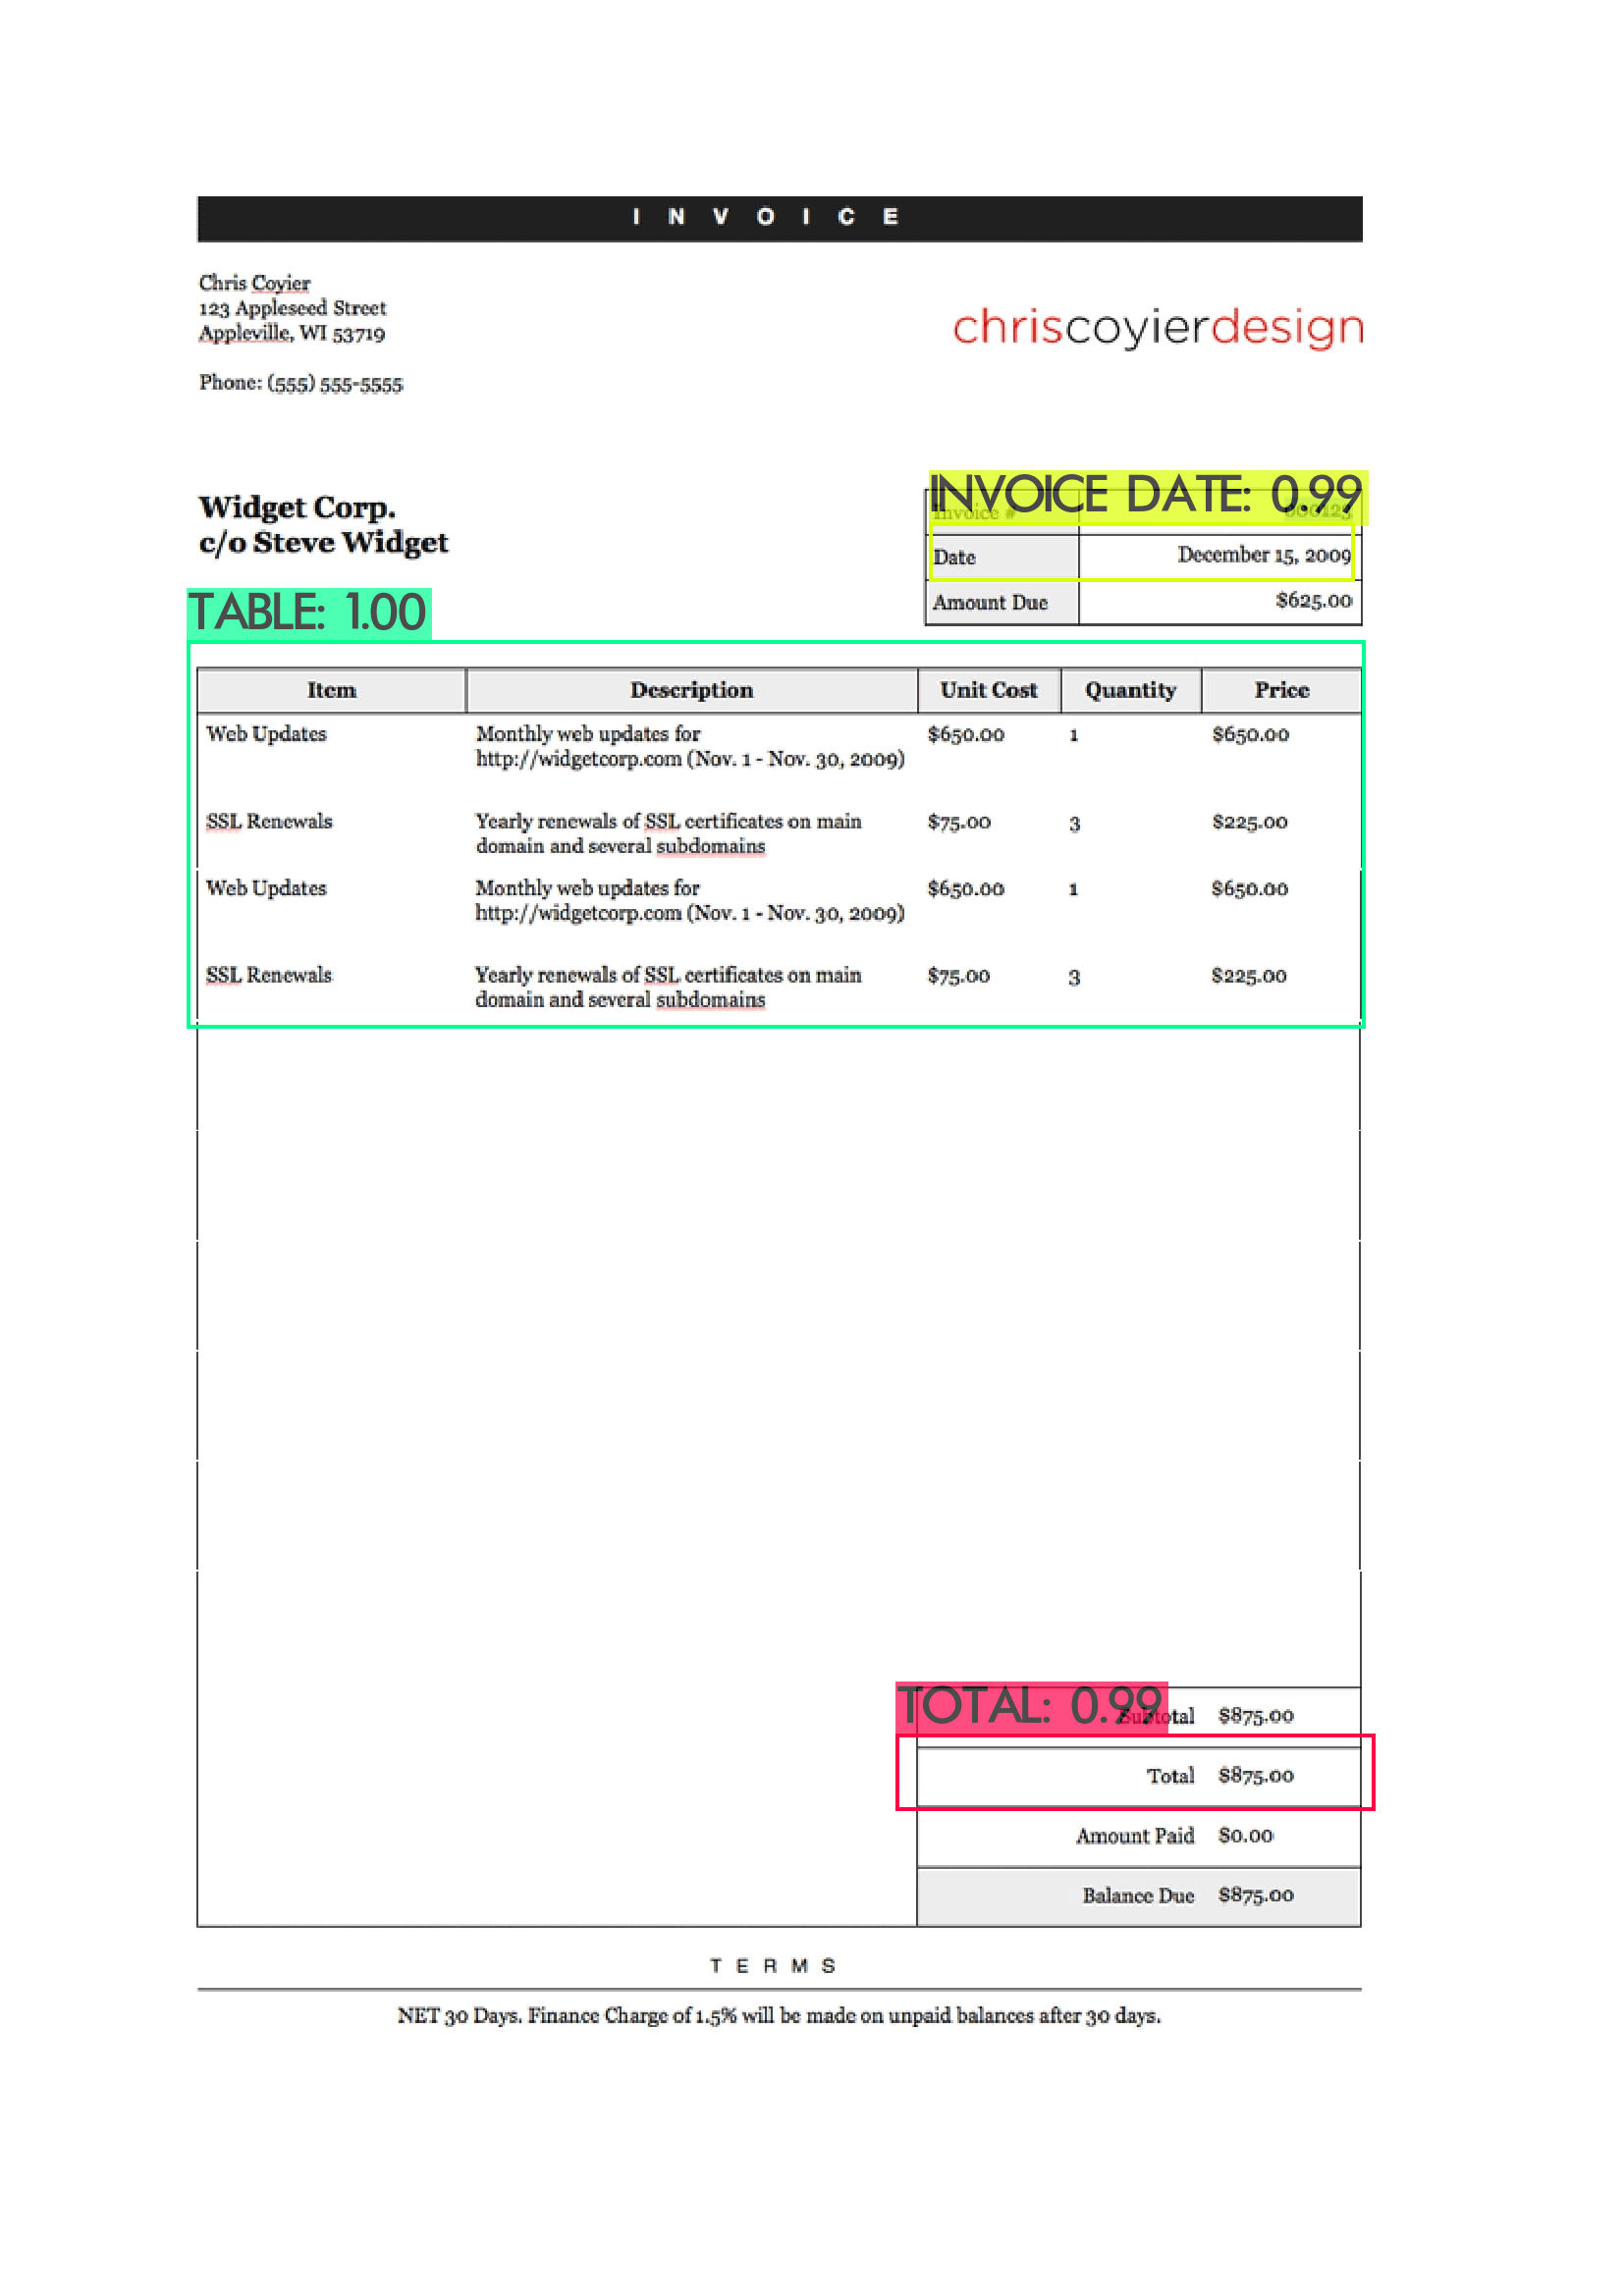

In [ ]:
from IPython.display import Image
Image(filename='predictions.jpg')